## Упражнения

- Загрузите два временных ряда `arma_ts1` и `arma_ts2`, выполнив код ниже.

In [2]:
import requests
import numpy as np
from io import BytesIO

# Load the first time series
response = requests.get("https://zenodo.org/records/10951538/files/arma_ts3.npz?download=1")
response.raise_for_status()
arma_ts1 = np.load(BytesIO(response.content))['signal']
print(len(arma_ts1))

# Load the second time series
response = requests.get("https://zenodo.org/records/10951538/files/arma_ts4.npz?download=1")
response.raise_for_status()
arma_ts2 = np.load(BytesIO(response.content))['signal']
print(len(arma_ts2))

479
1000


Для каждого временного ряда:

1. Разделите временной ряд на обучающий и тестовый.
    - Используйте последние 30 значений в качестве тестовых для первого временного ряда.
    - Используйте последние 100 значений в качестве тестовых для второго временного ряда.
2. Сделайте временной ряд стационарным.
3. Определите порядок $p$ модели AR.
4. Вычислите прогноз тестовых данных с помощью модели AR($p$).
5. Определите порядок $q$ модели MA.
6. Вычислите прогноз тестовых данных с помощью модели MA($q$).

**Упражнение:**

Dominant Frequency: 0.082
Dominant Period: 12.14 time units

[arma_ts1] period≈12, train=449, test=30
  AR(p): p=3, AIC=1251.9, resid_adf_p=0.0000, diff=False, MSE=2.158
  MA(q): q=12, AIC=1288.3, resid_adf_p=0.0000, diff=False, MSE=1.921


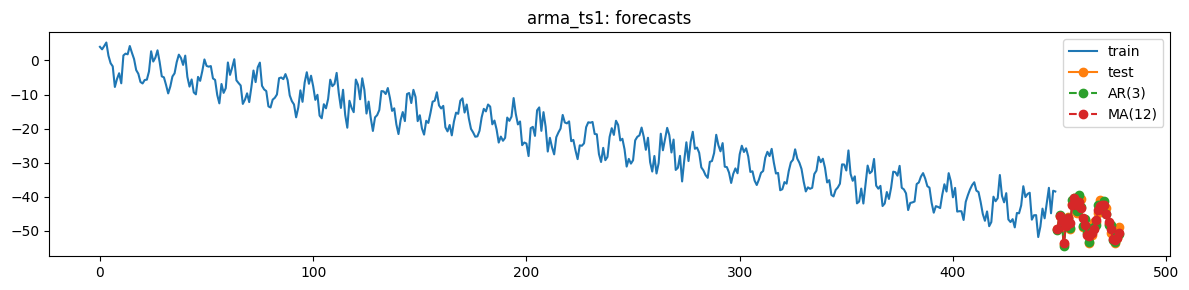

Dominant Frequency: 0.042
Dominant Period: 23.68 time units

[arma_ts2] period≈24, train=900, test=100
  AR(p): p=9, AIC=2538.7, resid_adf_p=0.0000, diff=False, MSE=1.700
  MA(q): q=1, AIC=2511.5, resid_adf_p=0.0000, diff=False, MSE=1.692


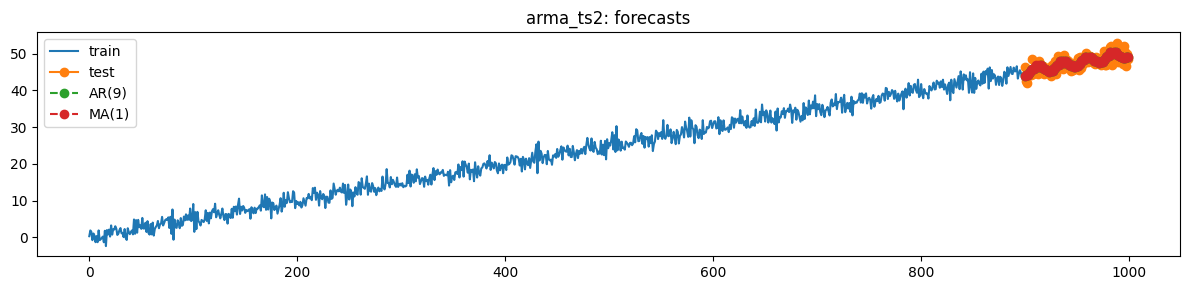

In [14]:
# AR(p) и MA(q) для двух временных рядов
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error

def fft_analysis(signal):

    # Linear detrending
    slope, intercept = np.polyfit(np.arange(len(signal)), signal, 1)
    trend = np.arange(len(signal)) * slope + intercept
    detrended = signal - trend

    fft_values = fft(detrended)
    frequencies = np.fft.fftfreq(len(fft_values))

    # Remove negative frequencies and sort
    positive_frequencies = frequencies[frequencies > 0]
    magnitudes = np.abs(fft_values)[frequencies > 0]

    # Identify dominant frequency
    dominant_frequency = positive_frequencies[np.argmax(magnitudes)]
    print(f"Dominant Frequency: {dominant_frequency:.3f}")

    # Convert frequency to period (e.g., days, weeks, months, etc.)
    dominant_period = 1 / dominant_frequency
    print(f"Dominant Period: {dominant_period:.2f} time units")

    return dominant_period, positive_frequencies, magnitudes

def _adf_pvalue(x: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    stat, pvalue, *_ = adfuller(x, autolag="AIC", result_object=False)
    return float(pvalue)

def _clip_period(p: float, fallback: int = 12, min_p: int = 2, max_p: int = 60) -> int:
    try:
        p_i = int(round(float(p)))
    except Exception:
        return fallback
    return p_i if (min_p <= p_i <= max_p) else fallback

def _estimate_period(y: np.ndarray, fallback: int = 12) -> int:
    p, _, _ = fft_analysis(np.asarray(y, dtype=float))
    return _clip_period(p, fallback=fallback)

def _fit_tes_baseline(train: np.ndarray, seasonal_periods: int | None):
    if seasonal_periods is not None and (len(train) < 2 * seasonal_periods):
        seasonal_periods = None
    if seasonal_periods is None:
        model = ExponentialSmoothing(train, trend="add", seasonal=None, initialization_method="estimated")
    else:
        model = ExponentialSmoothing(
            train,
            trend="add",
            seasonal="add",
            seasonal_periods=int(seasonal_periods),
            initialization_method="estimated",
        )
    return model.fit(optimized=True)

def _best_aic_order(y: np.ndarray, kind: str, max_order: int = 12):
    y = np.asarray(y, dtype=float)
    best = None
    for k in range(1, max_order + 1):
        order = (k, 0, 0) if kind == "ar" else (0, 0, k)
        try:
            res = ARIMA(y, order=order).fit()
            cand = (float(res.aic), k, res)
        except Exception:
            continue
        if best is None or cand[0] < best[0]:
            best = cand
    if best is None:
        raise RuntimeError(f"Failed to fit any {kind} model")
    return best  # (aic, order_k, fitted_result)

def _forecast_residual(train_resid: np.ndarray, horizon: int, kind: str):
    # Стараемся сделать остатки стационарными (если нужно — 1-я разность)
    p_raw = _adf_pvalue(train_resid)
    use_diff = p_raw > 0.05
    if use_diff:
        y = np.diff(train_resid)
        last = float(train_resid[-1])
    else:
        y = train_resid
        last = None

    aic, k, fitted = _best_aic_order(y, kind=kind, max_order=12)
    pred = np.asarray(fitted.forecast(horizon), dtype=float)
    if use_diff:
        pred = last + np.cumsum(pred)
    return pred, k, aic, use_diff, p_raw

def _solve_one(ts: np.ndarray, test_horizon: int, title: str):
    ts = np.asarray(ts, dtype=float)
    train, test = ts[:-test_horizon], ts[-test_horizon:]
    period = _estimate_period(train, fallback=12)

    # Базовая модель на тренд+сезонность (TES), затем моделируем остатки AR/MA
    tes_fit = _fit_tes_baseline(train, seasonal_periods=period)
    base_forecast = np.asarray(tes_fit.forecast(test_horizon), dtype=float)
    base_fitted = np.asarray(tes_fit.fittedvalues, dtype=float)
    resid_train = train - base_fitted

    ar_resid_pred, p, ar_aic, ar_diff, ar_pval = _forecast_residual(resid_train, test_horizon, kind="ar")
    ma_resid_pred, q, ma_aic, ma_diff, ma_pval = _forecast_residual(resid_train, test_horizon, kind="ma")

    ar_pred = base_forecast + ar_resid_pred
    ma_pred = base_forecast + ma_resid_pred

    mse_ar = mean_squared_error(test, ar_pred)
    mse_ma = mean_squared_error(test, ma_pred)

    print(f"\n[{title}] period≈{period}, train={len(train)}, test={len(test)}")
    print(f"  AR(p): p={p}, AIC={ar_aic:.1f}, resid_adf_p={ar_pval:.4f}, diff={ar_diff}, MSE={mse_ar:.3f}")
    print(f"  MA(q): q={q}, AIC={ma_aic:.1f}, resid_adf_p={ma_pval:.4f}, diff={ma_diff}, MSE={mse_ma:.3f}")

    # График train/test/forecast
    t = np.arange(len(ts))
    fig, ax = plt.subplots(1, 1, figsize=(12, 3))
    ax.plot(t[:-test_horizon], train, label="train")
    ax.plot(t[-test_horizon:], test, "o-", label="test")
    ax.plot(t[-test_horizon:], ar_pred, "o--", label=f"AR({p})")
    ax.plot(t[-test_horizon:], ma_pred, "o--", label=f"MA({q})")
    ax.set_title(f"{title}: forecasts")
    ax.legend()
    plt.tight_layout(); plt.show()

    return {
        "period": period,
        "p": p,
        "q": q,
        "mse_ar": float(mse_ar),
        "mse_ma": float(mse_ma),
    }

res1 = _solve_one(arma_ts1, test_horizon=30, title="arma_ts1")
res2 = _solve_one(arma_ts2, test_horizon=100, title="arma_ts2")


Dominant Frequency: 0.082
Dominant Period: 12.14 time units

[arma_ts1] train=449, test=30, period≈12
  ADF p-value raw=0.9329, diff1=0.0000, seasonal_diff=0.0000


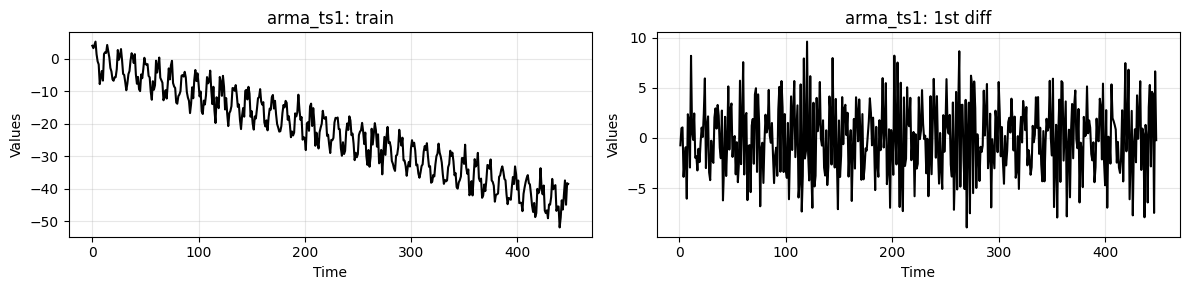

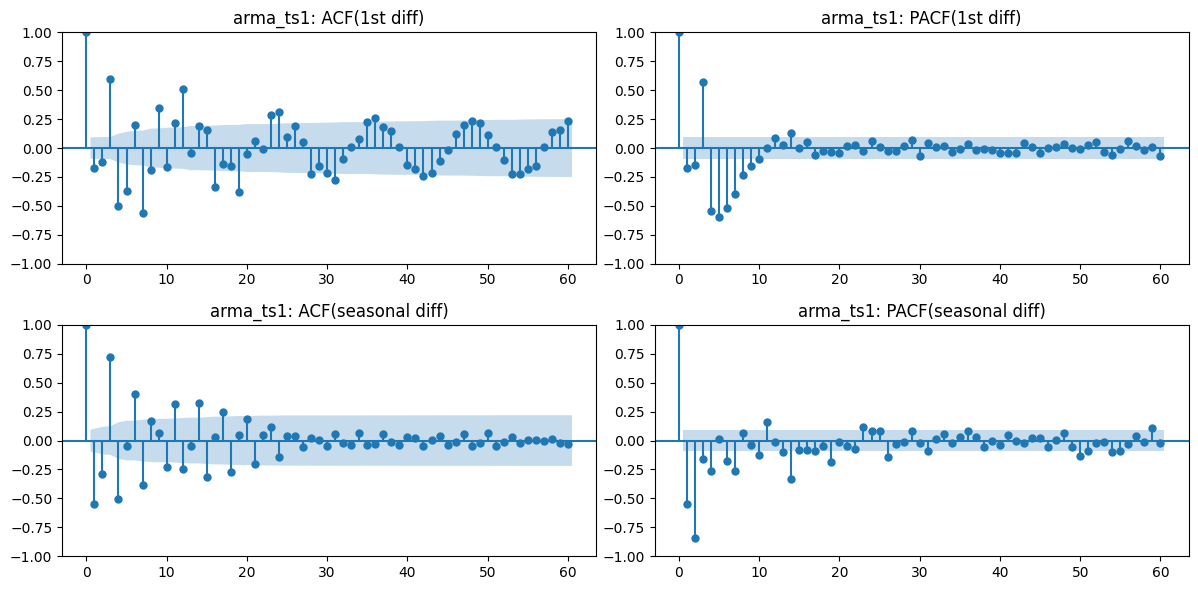

Dominant Frequency: 0.042
Dominant Period: 23.68 time units

[arma_ts2] train=900, test=100, period≈24
  ADF p-value raw=0.9471, diff1=0.0000, seasonal_diff=0.0000


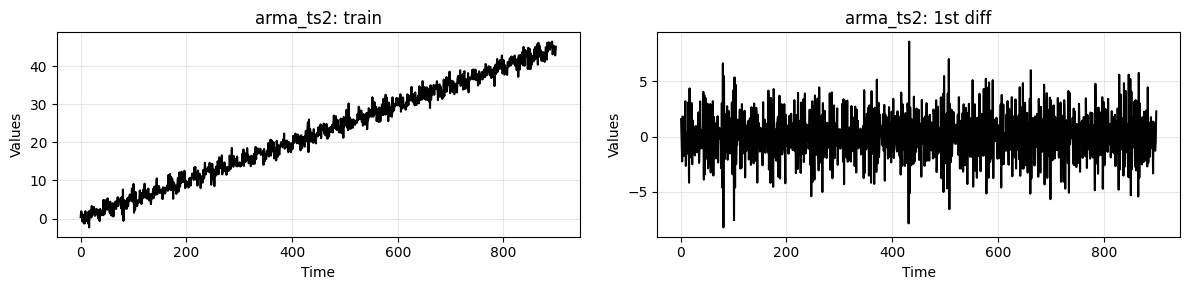

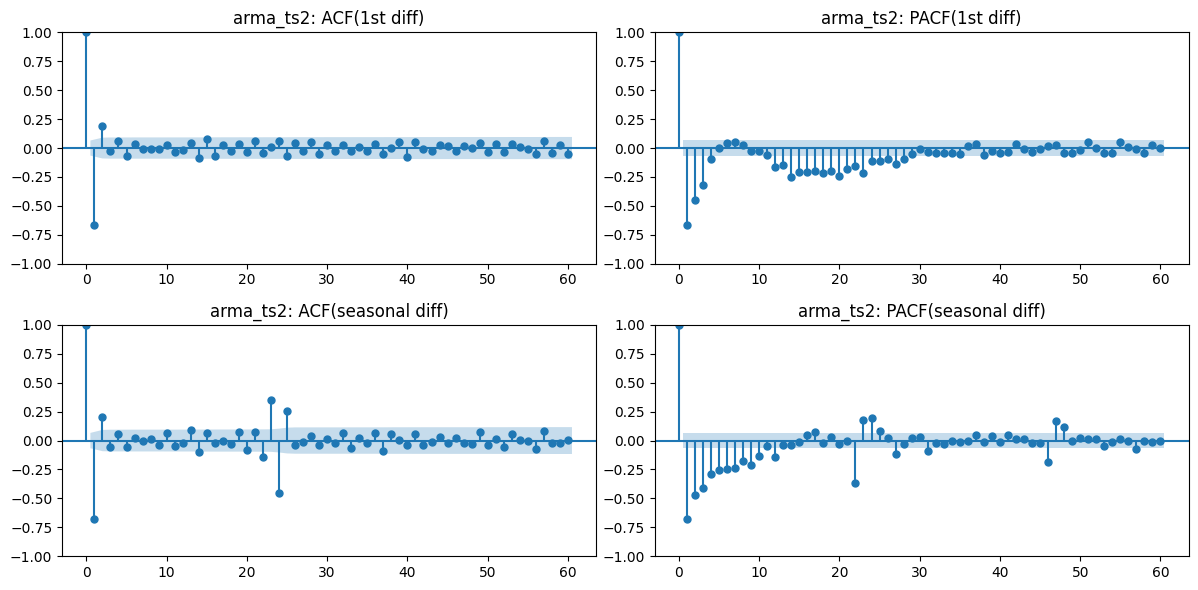

In [16]:
# Дополнительная диагностика стационарности и лаговой структуры (для качества решения)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Из лекции 2
def run_sequence_plot(x, y, title, xlabel="Time", ylabel="Values", ax=None):
    if ax is None:
        _, ax = plt.subplots(1,1, figsize=(10, 3.5))
    ax.plot(x, y, 'k-')
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3)
    return ax

def _diagnostics(ts: np.ndarray, test_horizon: int, fallback_period: int, title: str):
    ts = np.asarray(ts, dtype=float)
    train, test = ts[:-test_horizon], ts[-test_horizon:]
    t_train = np.arange(len(train), dtype=int)

    diff1 = np.diff(train)
    period = _estimate_period(train, fallback=fallback_period)
    if len(diff1) > period:
        seasonal_diff = diff1[period:] - diff1[:-period]
    else:
        seasonal_diff = diff1.copy()

    p_raw = _adf_pvalue(train)
    p_diff = _adf_pvalue(diff1)
    p_seas = _adf_pvalue(seasonal_diff)

    print(f"\n[{title}] train={len(train)}, test={len(test)}, period≈{period}")
    print(f"  ADF p-value raw={p_raw:.4f}, diff1={p_diff:.4f}, seasonal_diff={p_seas:.4f}")

    # Визуальное сравнение до/после стационаризации
    fig, axes = plt.subplots(1, 2, figsize=(12, 3))
    run_sequence_plot(t_train, train, title=f"{title}: train", ax=axes[0])
    run_sequence_plot(t_train[1:], diff1, title=f"{title}: 1st diff", ax=axes[1])
    plt.tight_layout(); plt.show()

    # Лаговые сравнения ACF/PACF
    fig, axes = plt.subplots(2, 2, figsize=(12, 6))
    plot_acf(diff1, lags=min(60, len(diff1) // 2), ax=axes[0, 0])
    axes[0, 0].set_title(f"{title}: ACF(1st diff)")
    plot_pacf(diff1, lags=min(60, len(diff1) // 2), method="ywm", ax=axes[0, 1])
    axes[0, 1].set_title(f"{title}: PACF(1st diff)")
    plot_acf(seasonal_diff, lags=min(60, len(seasonal_diff) // 2), ax=axes[1, 0])
    axes[1, 0].set_title(f"{title}: ACF(seasonal diff)")
    plot_pacf(seasonal_diff, lags=min(60, len(seasonal_diff) // 2), method="ywm", ax=axes[1, 1])
    axes[1, 1].set_title(f"{title}: PACF(seasonal diff)")
    plt.tight_layout(); plt.show()

    return {
        "title": title,
        "train": train,
        "test": test,
        "period": period,
        "diff1": diff1,
        "seasonal_diff": seasonal_diff,
        "adf_raw": p_raw,
        "adf_diff": p_diff,
        "adf_seasonal": p_seas,
    }

diag1 = _diagnostics(arma_ts1, test_horizon=30, fallback_period=12, title="arma_ts1")
diag2 = _diagnostics(arma_ts2, test_horizon=100, fallback_period=24, title="arma_ts2")



Top AIC lags for arma_ts1:
 lag      AR AIC
  11 1508.503495
  12 1510.328704
  10 1517.690334
 lag      MA AIC
  12 1357.064142
  11 1369.155556
  10 1400.542436

Top AIC lags for arma_ts2:
 lag      AR AIC
  12 3187.457827
  11 3228.017810
  10 3237.472892
 lag      MA AIC
   3 3054.001734
   2 3054.608893
   5 3058.577420


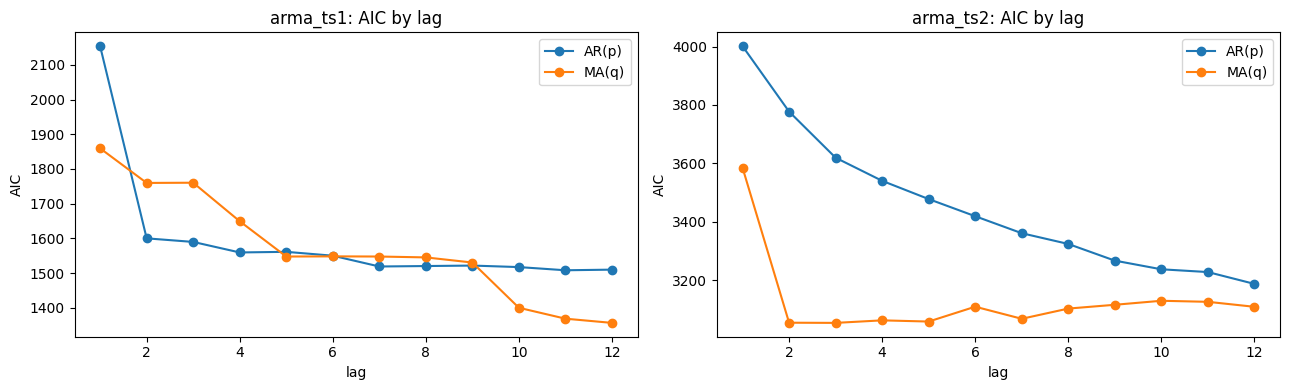

,series,period,best_ar_lag_by_aic,best_ma_lag_by_aic,selected_p,selected_q,mse_ar,mse_ma
0,arma_ts1,12,11,12,3,12,2.158235,1.921350
1,arma_ts2,24,12,3,9,1,1.699971,1.692108


In [19]:
# Убрать warnings
import warnings
from statsmodels.tools.sm_exceptions import EstimationWarning

warnings.filterwarnings("ignore", category=EstimationWarning)

# Диагностика выбора p/q: сравнение AIC по лагам для AR(p) и MA(q)
def _scan_aic_orders(y: np.ndarray, max_order: int = 12):
    y = np.asarray(y, dtype=float)
    rows = []
    for k in range(1, max_order + 1):
        try:
            aic_ar = float(ARIMA(y, order=(k, 0, 0)).fit().aic)
        except Exception:
            aic_ar = np.nan
        try:
            aic_ma = float(ARIMA(y, order=(0, 0, k)).fit().aic)
        except Exception:
            aic_ma = np.nan
        rows.append((k, aic_ar, aic_ma))
    return pd.DataFrame(rows, columns=["lag", "aic_ar", "aic_ma"])

scan1 = _scan_aic_orders(diag1["seasonal_diff"], max_order=12)
scan2 = _scan_aic_orders(diag2["seasonal_diff"], max_order=12)

def _best_lag(df: pd.DataFrame, col: str) -> int:
    valid = df[["lag", col]].dropna()
    return int(valid.loc[valid[col].idxmin(), "lag"])

print("\nTop AIC lags for arma_ts1:")
print(scan1.sort_values("aic_ar").head(3)[["lag", "aic_ar"]].rename(columns={"aic_ar": "AR AIC"}).to_string(index=False))
print(scan1.sort_values("aic_ma").head(3)[["lag", "aic_ma"]].rename(columns={"aic_ma": "MA AIC"}).to_string(index=False))

print("\nTop AIC lags for arma_ts2:")
print(scan2.sort_values("aic_ar").head(3)[["lag", "aic_ar"]].rename(columns={"aic_ar": "AR AIC"}).to_string(index=False))
print(scan2.sort_values("aic_ma").head(3)[["lag", "aic_ma"]].rename(columns={"aic_ma": "MA AIC"}).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
axes[0].plot(scan1["lag"], scan1["aic_ar"], "o-", label="AR(p)")
axes[0].plot(scan1["lag"], scan1["aic_ma"], "o-", label="MA(q)")
axes[0].set_title("arma_ts1: AIC by lag")
axes[0].set_xlabel("lag"); axes[0].set_ylabel("AIC"); axes[0].legend()

axes[1].plot(scan2["lag"], scan2["aic_ar"], "o-", label="AR(p)")
axes[1].plot(scan2["lag"], scan2["aic_ma"], "o-", label="MA(q)")
axes[1].set_title("arma_ts2: AIC by lag")
axes[1].set_xlabel("lag"); axes[1].set_ylabel("AIC"); axes[1].legend()
plt.tight_layout(); plt.show()

summary_df = pd.DataFrame([
    {
        "series": "arma_ts1",
        "period": diag1["period"],
        "best_ar_lag_by_aic": _best_lag(scan1, "aic_ar"),
        "best_ma_lag_by_aic": _best_lag(scan1, "aic_ma"),
        "selected_p": res1["p"],
        "selected_q": res1["q"],
        "mse_ar": res1["mse_ar"],
        "mse_ma": res1["mse_ma"],
    },
    {
        "series": "arma_ts2",
        "period": diag2["period"],
        "best_ar_lag_by_aic": _best_lag(scan2, "aic_ar"),
        "best_ma_lag_by_aic": _best_lag(scan2, "aic_ma"),
        "selected_p": res2["p"],
        "selected_q": res2["q"],
        "mse_ar": res2["mse_ar"],
        "mse_ma": res2["mse_ma"],
    },
])

display(summary_df)
